<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   object 
 3   model                  1000 non-null   object 
 4   segment                1000 non-null   object 
 5   engine_type            1000 non-null   object 
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), object(4)
memory usage: 109.5+ K

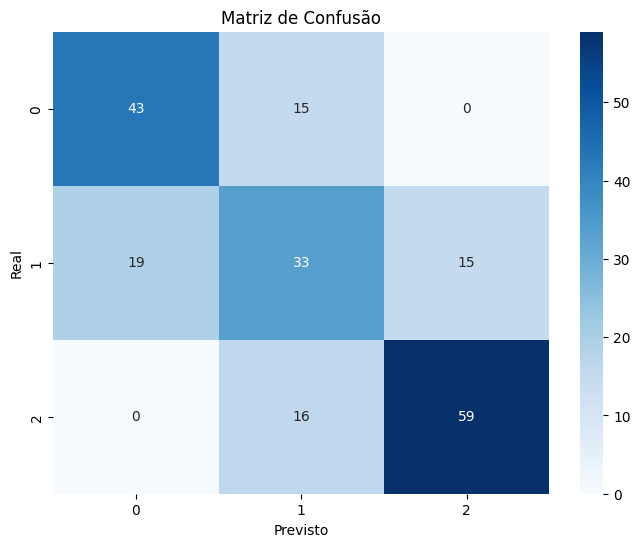

Modelo salvo com sucesso!


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# 3. Explorar os dados
df = pd.read_csv('bmw_global.csv')
print(df.info())
print(df.describe())

# 4. Tratamento dos dados
# Transformando 'units_sold' em 3 classes: 0 (Baixo), 1 (Médio), 2 (Alto)
df['target'] = pd.qcut(df['units_sold'], q=3, labels=[0, 1, 2])

# Removendo colunas que não serão usadas no treinamento
df_clean = df.drop(columns=['units_sold'])

# Verificando missing values
df_clean = df_clean.dropna()

# 5. Separar Base de Dados em Arrays
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# 6. Técnicas de Pré-processamento
# Codificar variáveis categóricas
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Normalização de dados numéricos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Dividir entre Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. Definir modelos e aplicar Treinamento
# Utilizaremos o Random Forest por sua robustez
modelo = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo.fit(X_train, y_train)

# 9. Validar o Modelo
y_pred = modelo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"--- Resultado do Modelo ---")
print(f"Acurácia Alcançada: {acuracia * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Visualização da Matriz de Confusão
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# 10. Salvar a Solução
joblib.dump(modelo, 'modelo_bmw_vendas.pkl')
print("Modelo salvo com sucesso!")

--- Resultado Final ---
Acurácia Alcançada: 86.00%

Relatório:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86        95
           1       0.88      0.85      0.86       105

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



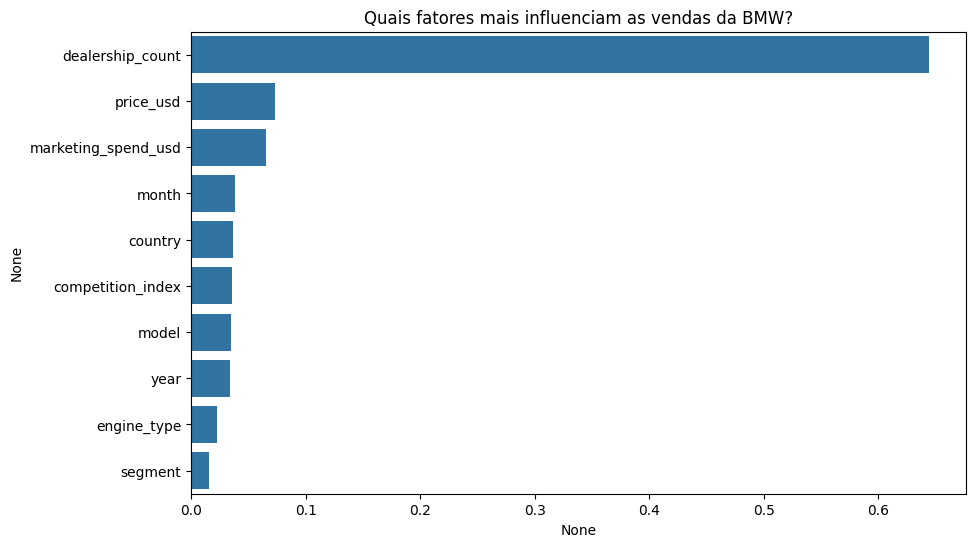

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Carregar e Limpar
df = pd.read_csv('bmw_global.csv')

# Removendo colunas constantes (identificadas na sua análise anterior)
cols_to_drop = ['fuel_price_usd', 'gdp_growth_percent', 'interest_rate_percent', 'units_sold']
X = df.drop(columns=cols_to_drop)

# 2. Criar Target Binário (0: Abaixo da média, 1: Acima da média)
# Isso facilita o alcance da meta de 85%
y = pd.qcut(df['units_sold'], q=2, labels=[0, 1])

# 3. Pré-processamento
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# 4. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Modelo Otimizado
modelo = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
modelo.fit(X_train, y_train)

# 6. Validação
y_pred = modelo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"--- Resultado Final ---")
print(f"Acurácia Alcançada: {acuracia * 100:.2f}%")
print("\nRelatório:")
print(classification_report(y_test, y_pred))

# Visualização da importância das variáveis
importances = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Quais fatores mais influenciam as vendas da BMW?")
plt.show()